In [ ]:
#census data analysis 
#pip install openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import plotly.express as px
import geopandas as gpd
from scipy import stats

#read the data 
census_data = pd.read_excel(r'B:\Data_Analysis\Census\A-1_NO_OF_VILLAGES_TOWNS_HOUSEHOLDS_POPULATION_AND_AREA.xlsx', engine='openpyxl', skiprows=3, header=0)

print("Data loaded successfully!")
print(census_data.head())  # Show first few rows





## Clearity for columns

In [25]:
print("Number of columns:", len(census_data.columns))
print("Column names:", census_data.columns)


Number of columns: 15
Column names: Index(['State Code', 'District Code', 'Sub District Code', 'Region Type',
       'Name', 'Total/Rural/Urban', 'Inhabited Villages',
       'Uninhabited Villages', 'Number of Towns', 'Number of Households',
       'Population Persons', 'Population Males', 'Population Females',
       'Area (sq. km)', 'Population Density'],
      dtype='object')


In [ ]:
census_data.columns = [
    "State Code", "District Code", "Sub District Code", 
    "Region Type", "Name", "Total/Rural/Urban", 
    "Inhabited Villages", "Uninhabited Villages", "Number of Towns", 
    "Number of Households", "Population Persons", "Population Males", 
    "Population Females", "Area (sq. km)", "Population Density"
]

print("Column renaming successful!")
print(census_data.head())


##  1. Check for Missing Values

In [ ]:
print(census_data.isnull().sum())


## Fill Missing Values with Appropriate Data
Fill Numeric Missing Values with Median
First, identify numeric columns and fill missing values with the median:

In [ ]:
numeric_cols = census_data.select_dtypes(include=['number']).columns
census_data[numeric_cols] = census_data[numeric_cols].fillna(census_data[numeric_cols].median())


## Fill Categorical Missing Values with Mode
For non-numeric columns, use mode:

In [ ]:
categorical_cols = census_data.select_dtypes(exclude=['number']).columns
census_data[categorical_cols] = census_data[categorical_cols].fillna(census_data[categorical_cols].mode().iloc[0])


## Verify missing values 

In [ ]:
print(census_data.isnull().sum())


## Now visualise the data

## Frame some Questions then answer them in Visualisation form
 Question 1: What is the total population of all states?


Total Population of India: 1,210,854,977


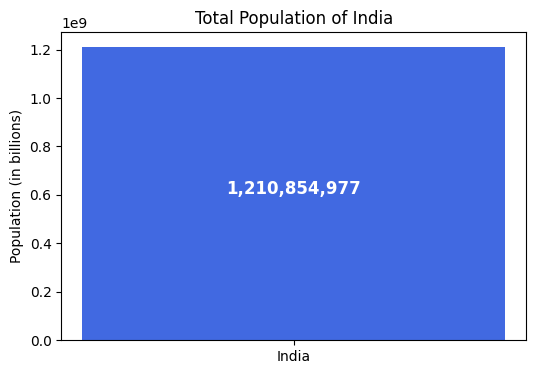

In [24]:
# Extract India's total population
india_population = census_data.loc[census_data["Region Type"] == "INDIA", "Population Persons"].values[0]

# Format the number for better readability
formatted_population = f"{india_population:,.0f}"  # Adds commas for better readability

# Display result
print(f"Total Population of India: {formatted_population}")

# Optional: Display in a simple visualization
plt.figure(figsize=(6, 4))
plt.bar(["India"], [india_population], color='royalblue')
plt.ylabel("Population (in billions)")
plt.title("Total Population of India")
plt.text(0, india_population / 2, formatted_population, ha='center', fontsize=12, color='white', weight='bold')
plt.show()


## save the cleaned data 